# Exploratory Data Analysis

The baseline picture of the business before any modelling. Four questions:

1. How are Sales, Discount, Profit, and Quantity actually distributed?
2. Which categories and sub-categories carry sales, and which carry profit?
3. Are those the same thing?
4. What moves with what?

Data comes from the validated Parquet in `data/processed/`, so this notebook runs off the
same tables as the SQL suite rather than re-reading the raw CSV.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import plotting as viz
from src.utils import load_analysis_frame

viz.apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
df = load_analysis_frame()
print(f"{len(df):,} order lines, {df.shape[1]} columns")
print(f"orders {df['order_date'].min()} to {df['order_date'].max()}")
df.head(3)

9,994 order lines, 32 columns
orders 2017-01-03 to 2020-12-30


,row_id,order_id,order_date,ship_date,ship_mode,customer_key,product_key,geography_key,order_date_key,ship_date_key,sales,quantity,discount,profit,is_loss_making,customer_id,customer_name,segment,product_id,category,sub_category,product_name,country,city,state,postal_code,region,year,quarter,month,month_name,year_month
0,1,CA-2019-152156,2019-11-08,2019-11-11,Second Class,144,13,272,20191108,20191111,261.96,2,0.0,41.9136,False,CG-12520,Claire Gute,Consumer,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,United States,Henderson,Kentucky,42420.0,South,2019,4,11,November,2019-11
1,2,CA-2019-152156,2019-11-08,2019-11-11,Second Class,144,57,272,20191108,20191111,731.94,3,0.0,219.5820,False,CG-12520,Claire Gute,Consumer,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",United States,Henderson,Kentucky,42420.0,South,2019,4,11,November,2019-11
2,3,CA-2019-138688,2019-06-12,2019-06-16,Second Class,238,960,67,20190612,20190616,14.62,2,0.0,6.8714,False,DV-13045,Darrin Van Huff,Corporate,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,United States,Los Angeles,California,90036.0,West,2019,2,6,June,2019-06


## Summary statistics

The four measures on the fact table, plus the margin implied by each line.

In [3]:
df["margin_pct"] = 100 * df["profit"] / df["sales"]

summary = df[["sales", "quantity", "discount", "profit", "margin_pct"]].describe().T
summary["skew"] = df[["sales", "quantity", "discount", "profit", "margin_pct"]].skew()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
sales,9994.0,229.86,623.25,0.44,17.28,54.49,209.94,22638.48,12.97
quantity,9994.0,3.79,2.23,1.00,2.00,3.00,5.00,14.00,1.28
discount,9994.0,0.16,0.21,0.00,0.00,0.20,0.20,0.80,1.68
profit,9994.0,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98,7.56
margin_pct,9994.0,12.03,46.68,-275.00,7.50,27.00,36.25,50.00,-2.89


Three things stand out before any chart.

**Sales are severely right skewed.** The median line is about $54 while the mean is $230 and
the maximum is over $22,000. A handful of large orders dominate the total, so any average
quoted without a median beside it will mislead.

**Profit is roughly symmetric around a small positive number but has long tails both ways.**
The worst single line loses more than $6,500. Losses are not rounding errors.

**Discount is bimodal rather than continuous.** The mean of 0.16 sits between the two places
the data actually lives, 0% and 20%, which the histogram below makes obvious. This matters
later: a regression on discount is fitting a lumpy variable, not a smooth one.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


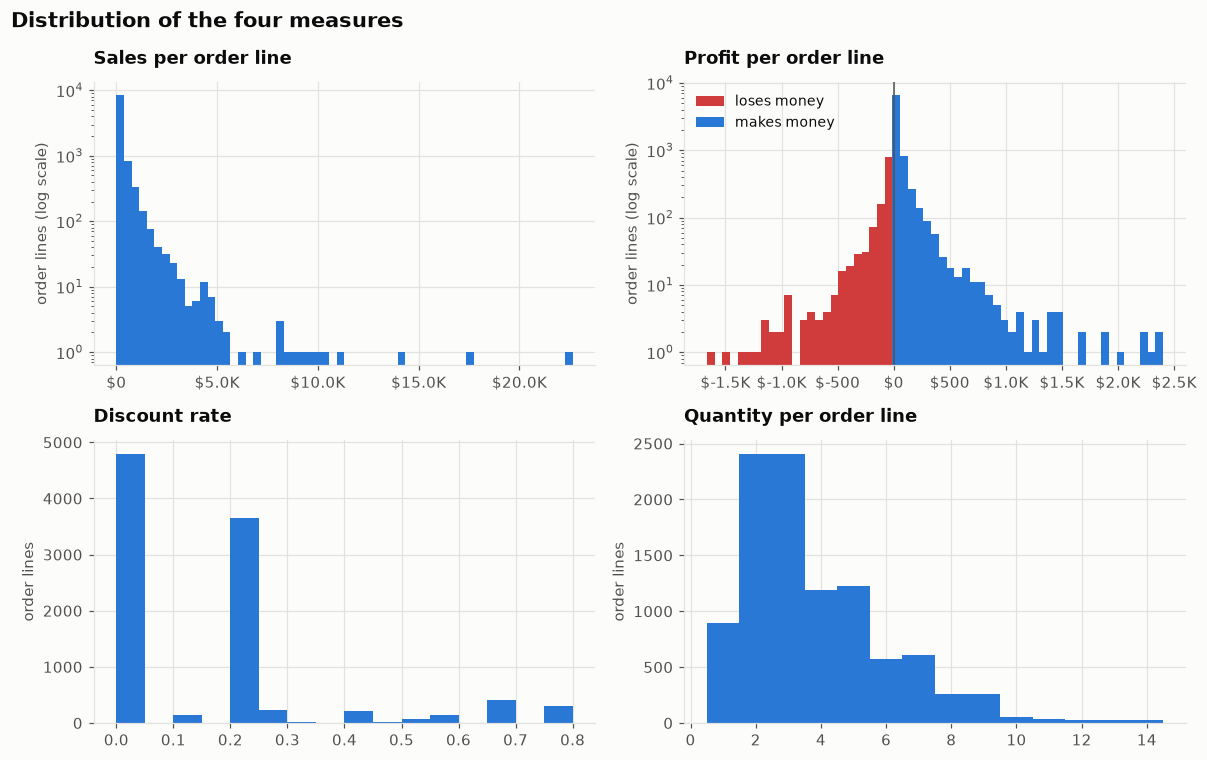

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

specs = [
    ("sales", "Sales per order line", "$", True),
    ("profit", "Profit per order line", "$", False),
    ("discount", "Discount rate", "", False),
    ("quantity", "Quantity per order line", "", False),
]

for ax, (col, title, unit, log) in zip(axes.ravel(), specs):
    if col == "profit":
        # Polarity is the message here, so split the bars at zero.
        losses = df.loc[df[col] < 0, col]
        gains = df.loc[df[col] >= 0, col]
        bins = np.linspace(df[col].quantile(0.001), df[col].quantile(0.999), 60)
        ax.hist(losses, bins=bins, color=viz.PROFIT_NEGATIVE, label="loses money")
        ax.hist(gains, bins=bins, color=viz.PROFIT_POSITIVE, label="makes money")
        ax.axvline(0, color=viz.INK_MUTED, linewidth=1)
        # Without a log scale the spike of near-zero lines flattens both tails, which is
        # where the story is.
        ax.set_yscale("log")
        ax.set_ylabel("order lines (log scale)")
        ax.legend(loc="upper left", fontsize=9)
    elif col == "discount":
        ax.hist(df[col], bins=np.arange(0, 0.85, 0.05), color=viz.CATEGORICAL[0])
    elif col == "quantity":
        ax.hist(df[col], bins=np.arange(0.5, 15.5, 1), color=viz.CATEGORICAL[0])
    else:
        ax.hist(df[col], bins=60, color=viz.CATEGORICAL[0])
        ax.set_yscale("log")
        ax.set_ylabel("order lines (log scale)")

    ax.set_title(title)
    if unit == "$":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
    if not log and col != "profit":
        ax.set_ylabel("order lines")

fig.suptitle("Distribution of the four measures", x=0.005, ha="left", fontsize=14,
             fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "eda_distributions")
plt.show()

**Sales** needed a log y-axis to be readable at all, which is itself the finding: the bulk of
lines are small, and the revenue total is carried by a thin tail of large ones.

**Profit** is the chart to bring to a sales-ops review. The red mass to the left of zero is
1,871 order lines, 18.7% of the book. It is not a handful of edge cases.

**Discount** is the clearest structural fact in the dataset. Roughly half of all lines carry
no discount at all, there is a large spike at 20%, and the rest scatter thinly across 30% to
80%. The business is not tuning discounts finely; it is applying a few standard rates.

**Quantity** is small and tight, mostly two to five units. It will not explain much variation
in profit on its own.

## Where sales and profit come from

Sales and profit are plotted separately rather than on one dual axis, because the whole point
is that the two rankings disagree.

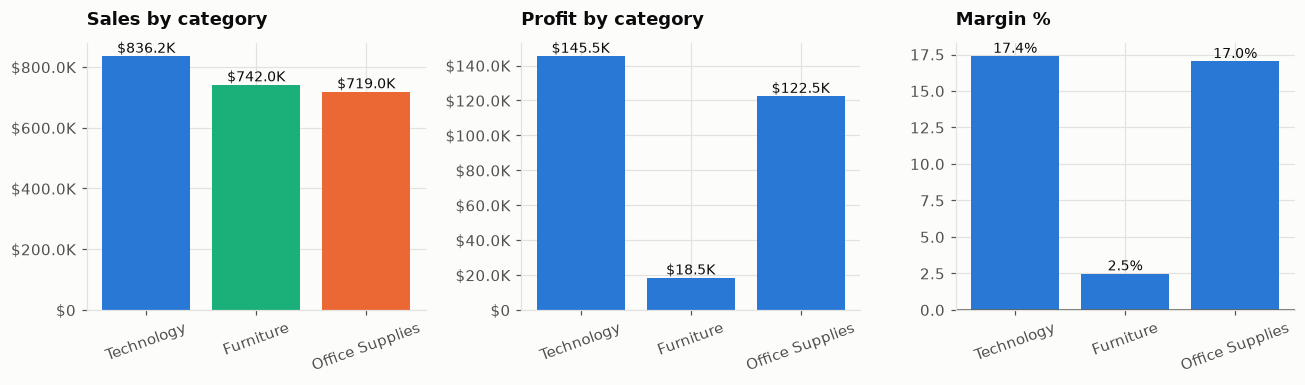

,sales,profit,margin_pct
category,,,
Technology,836154.03,145454.95,17.40
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04


In [5]:
by_cat = (
    df.groupby("category")[["sales", "profit"]].sum()
    .assign(margin_pct=lambda d: 100 * d["profit"] / d["sales"])
    .sort_values("sales", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

axes[0].bar(by_cat.index, by_cat["sales"], color=[viz.CATEGORY_COLORS[c] for c in by_cat.index])
axes[0].set_title("Sales by category")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))

axes[1].bar(by_cat.index, by_cat["profit"], color=viz.profit_colors(by_cat["profit"]))
axes[1].set_title("Profit by category")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))

axes[2].bar(by_cat.index, by_cat["margin_pct"], color=viz.profit_colors(by_cat["margin_pct"]))
axes[2].set_title("Margin %")
axes[2].axhline(0, color=viz.INK_MUTED, linewidth=1)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
for ax, col in zip(axes, ["sales", "profit", "margin_pct"]):
    for x, v in enumerate(by_cat[col]):
        label = f"{v:,.1f}%" if col == "margin_pct" else viz.currency(v)
        ax.annotate(label, (x, v), ha="center", va="bottom", fontsize=9, color=viz.INK)

fig.tight_layout()
viz.save_figure(fig, "eda_category_sales_profit")
plt.show()

by_cat.round(2)

Technology and Furniture sell almost the same amount, $836K against $742K. Technology returns
$145K of profit and Furniture returns $18K. Furniture is a fifth of the revenue and 6% of the
profit.

That gap is the project's question in one chart: the volume ranking and the profit ranking are
not the same ranking.

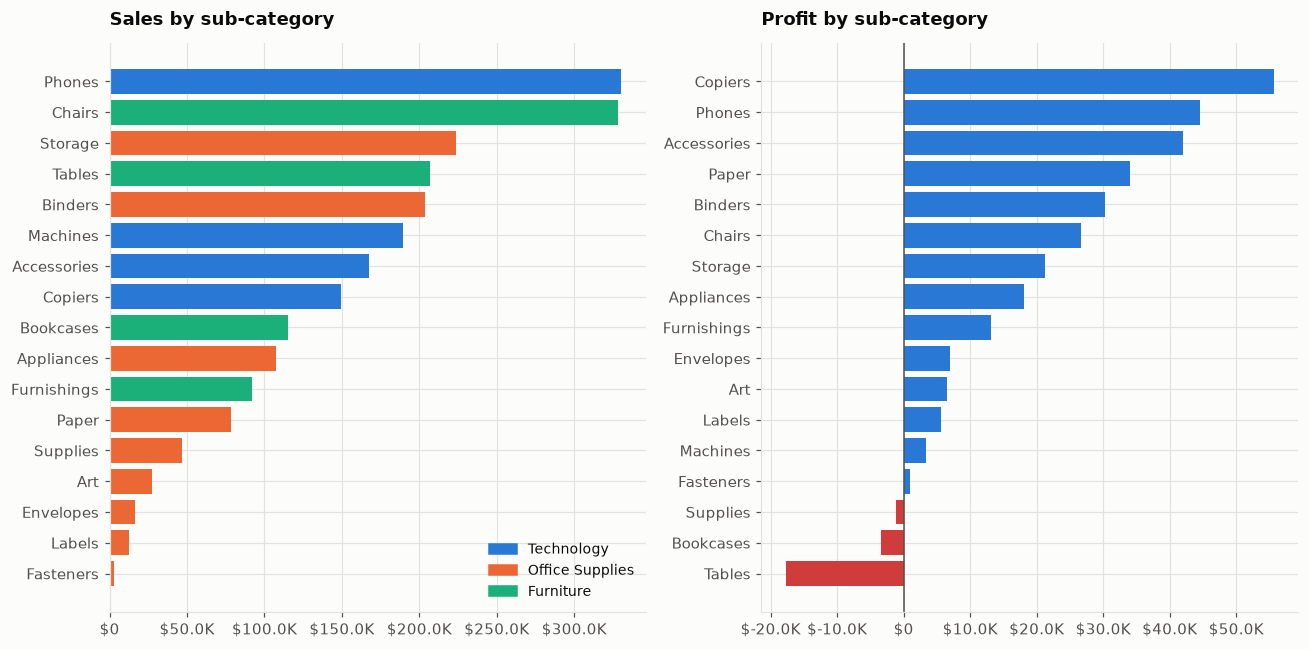

,sub_category,category,sales,profit,margin_pct
16,Tables,Furniture,206965.53,-17725.48,-8.56
4,Bookcases,Furniture,114880.00,-3472.56,-3.02
15,Supplies,Office Supplies,46673.54,-1189.10,-2.55
8,Fasteners,Office Supplies,3024.28,949.52,31.40
11,Machines,Technology,189238.63,3384.76,1.79
10,Labels,Office Supplies,12486.31,5546.25,44.42


In [6]:
by_sub = (
    df.groupby(["sub_category", "category"])[["sales", "profit"]].sum()
    .reset_index()
    .assign(margin_pct=lambda d: 100 * d["profit"] / d["sales"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

s = by_sub.sort_values("sales")
axes[0].barh(s["sub_category"], s["sales"],
             color=[viz.CATEGORY_COLORS[c] for c in s["category"]])
axes[0].set_title("Sales by sub-category")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(viz.currency))

p = by_sub.sort_values("profit")
axes[1].barh(p["sub_category"], p["profit"], color=viz.profit_colors(p["profit"]))
axes[1].set_title("Profit by sub-category")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
axes[1].axvline(0, color=viz.INK_MUTED, linewidth=1)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in viz.CATEGORY_COLORS.values()]
axes[0].legend(handles, viz.CATEGORY_COLORS.keys(), loc="lower right", fontsize=9)

fig.tight_layout()
viz.save_figure(fig, "eda_sub_category_sales_profit")
plt.show()

by_sub.sort_values("profit").round(2).head(6)

Three sub-categories are net negative over four years: **Tables at -$17,725, Bookcases at
-$3,473, and Supplies at -$1,189**. Tables is not a small line either. It sells $206,966,
which puts it in the top third by revenue while losing more money than any other line makes
except the top four.

Machines is the near miss worth watching: $189,238 of sales for $3,385 of profit, a 1.8%
margin. It takes very little movement in discounting to push it negative.

Copiers is the opposite case and the one to protect: only 68 order lines, but $55,618 of
profit at a 37% margin.

## What moves with what

Correlation across the four measures, plus margin. Diverging colour because the sign is the
information: blue is positive, red is negative, grey is nothing.

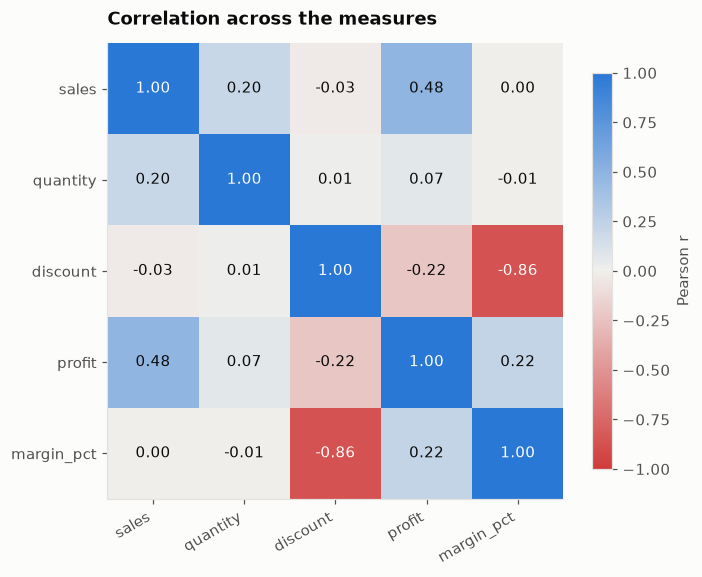

In [7]:
from matplotlib.colors import LinearSegmentedColormap

cols = ["sales", "quantity", "discount", "profit", "margin_pct"]
corr = df[cols].corr()

cmap = LinearSegmentedColormap.from_list(
    "profit_diverging", [viz.PROFIT_NEGATIVE, viz.NEUTRAL, viz.PROFIT_POSITIVE]
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=30, ha="right")
ax.set_yticks(range(len(cols)), cols)
ax.grid(False)

for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=10,
                color="#ffffff" if abs(value) > 0.55 else viz.INK)

fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation across the measures")
fig.tight_layout()
viz.save_figure(fig, "eda_correlation")
plt.show()

**Discount against margin is -0.86.** That is not a tendency, it is close to a mechanical
relationship: knowing the discount on a line tells you most of what there is to know about
whether it earned anything. Nothing else in the matrix comes close.

Discount against raw profit is only -0.22, and the gap between those two numbers is the
methodological point of this notebook. Profit is a dollar amount, so a heavily discounted
large order can still out-earn a small full-price one, which dilutes the signal. Margin
normalises for order size and the relationship snaps into focus. Margin is the right target
variable, and it is what the Phase 6 regression models.

Sales and quantity correlate only weakly at 0.20, so order size is driven by unit price
rather than units shipped. Quantity is unlikely to earn its place as a predictor.

Correlation is not causation and these are single-variable relationships. The regression in
`02_discount_profit_analysis.ipynb` controls for quantity and category to test whether the
discount effect survives.

## What to take into the next notebook

1. **Discount is the lever.** It correlates with margin at -0.86, stronger than anything else
   measured, and it is applied in a few coarse steps rather than tuned per deal.
2. **Furniture is the problem category**, and Tables and Bookcases are the problem lines
   inside it. Both sell well and both lose money.
3. **Margin, not profit, is the variable to model.** Profit in dollars confounds order size
   with pricing quality.
4. **Averages will mislead on this data.** Sales are heavily skewed, so medians and
   distributions belong in any summary that goes to a stakeholder.